In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent
from config_local import config
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

logger = logging.getLogger(__name__)

/home/markoc1120/src/nlp_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1>Wikispeedia dataset exploratory analysis</h1>

Let's get started by exploring the Wikispeedia dataset. The dataset is composed of six files:

articles.tsv, which contains the list of wikipedia articles


categories.tsv, which contains the list of wikipedia categories


links.tsv, which contains the list of links between articles


paths_finished.tsv, which contains the list of human paths finished by the users


paths_unfinished.tsv, which contains the list of human paths unfinished by the users


shortest-path-distance-matrix.txt, which contains the shortest path distance between each pair of articles


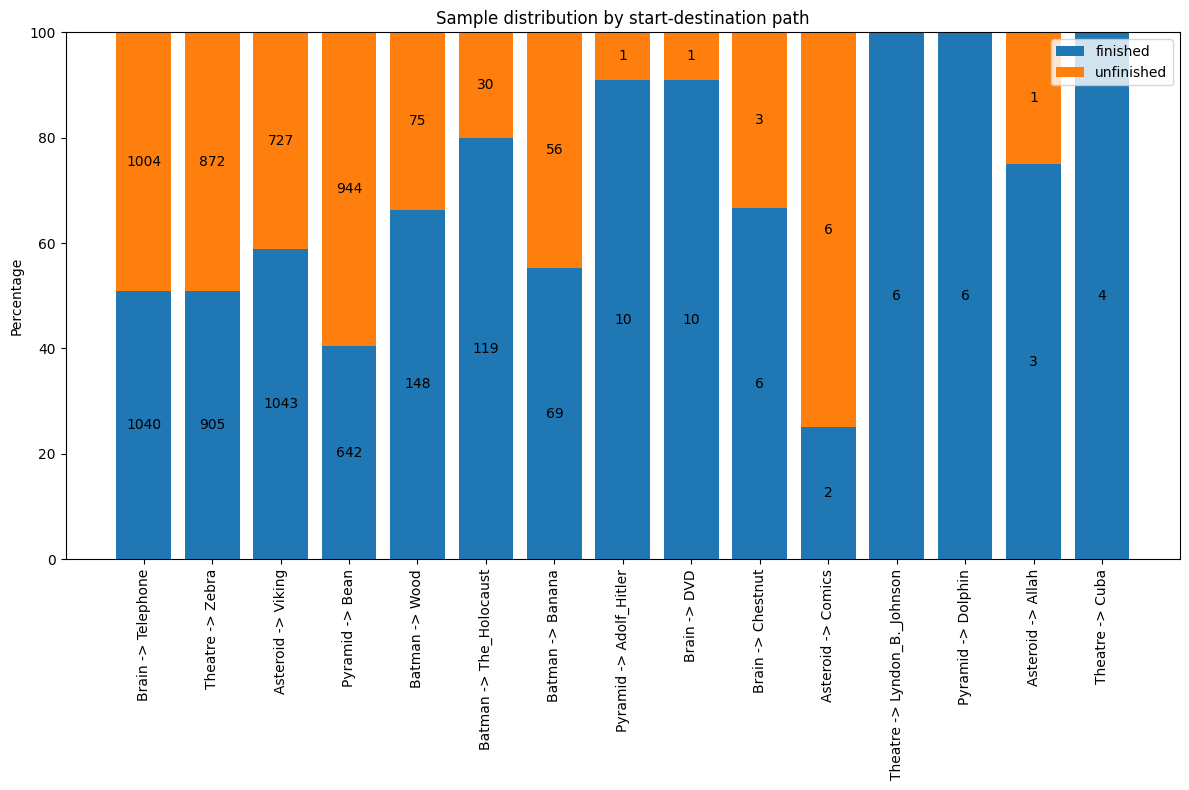

In [3]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

As shown above, we have a few start-destination pairs with a high number of paths.

<h3>Articles</h3>

In [4]:
# parsing auxiliary files into pd.DataFrame
articles = preprocessor.parse_input_file(config.input_file_articles)
categories = preprocessor.parse_input_file(config.input_file_categories)
links = preprocessor.parse_input_file(config.input_file_links)

In [5]:
# number of articles
print(f'Number of articles: {len(articles)}')

Number of articles: 4604


<h3>Links</h3>  

All of the articles have at least one outgoing or target link, thus we don't have any links which are unreachable. On average, each article appears ~26 times as source and ~29 as target.

*Source links' statistics*:

In [6]:
print(links['linkSource'].value_counts().describe())

count    4587.000000
mean       26.135165
std        24.194229
min         1.000000
25%        11.000000
50%        19.000000
75%        33.000000
max       294.000000
Name: count, dtype: float64


*Target links' statistics*:

In [7]:
print(links['linkTarget'].value_counts().describe())

count    4135.000000
mean       28.992019
std        65.560574
min         1.000000
25%         4.000000
50%        10.000000
75%        29.000000
max      1551.000000
Name: count, dtype: float64


<h3>Categories</h3>

We have 129 unique categories. Each articles has at most 3 categories. 

*Categories statistics*:

In [8]:
categories.describe()

,article,category
count,5204,5204
unique,4598,129
top,United_Kingdom,subject.Countries
freq,3,229


There are 43379 articles without categories (9.11%)

In [9]:
cat_df_clean, cat_df, article_cats_finished, article_cats = preprocessor.get_clean_categories_df(df, categories)

In [10]:
# Count missing categories
mis_count = cat_df.loc[cat_df["category"] == "Unknown", "count"].sum()
mis_perc = mis_count / len(article_cats) 

# Prints
print(f"'No. of unknown categories: {mis_count}")
print(f"'Unknown' categories account for approximately {mis_perc:.2%} of all entries.")

'No. of unknown categories: 33559
'Unknown' categories account for approximately 7.05% of all entries.


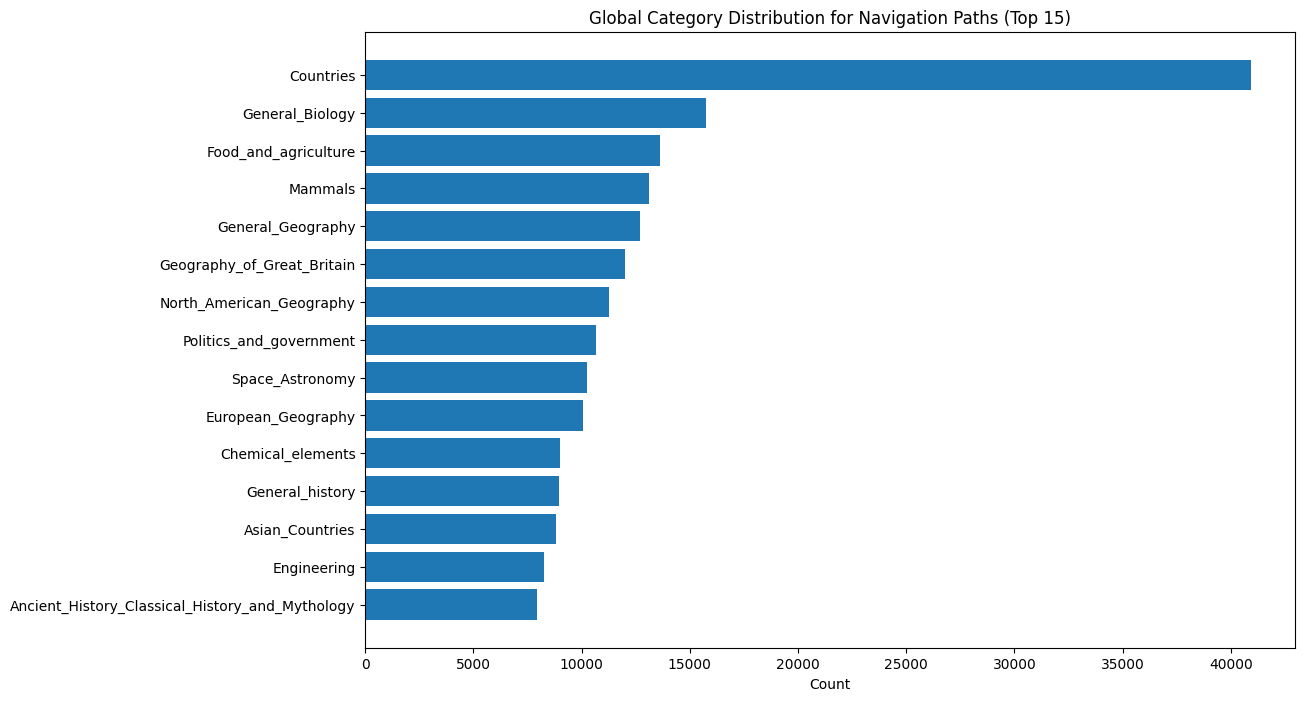

In [11]:
# Plot the 15 top categories while excluding missing categories
visualizer.visualize_category_distribution_for_paths(cat_df_clean, 'top_15_categories.png')

Countries is by far the most visited category

<h3>Categorical Shifts</h3>

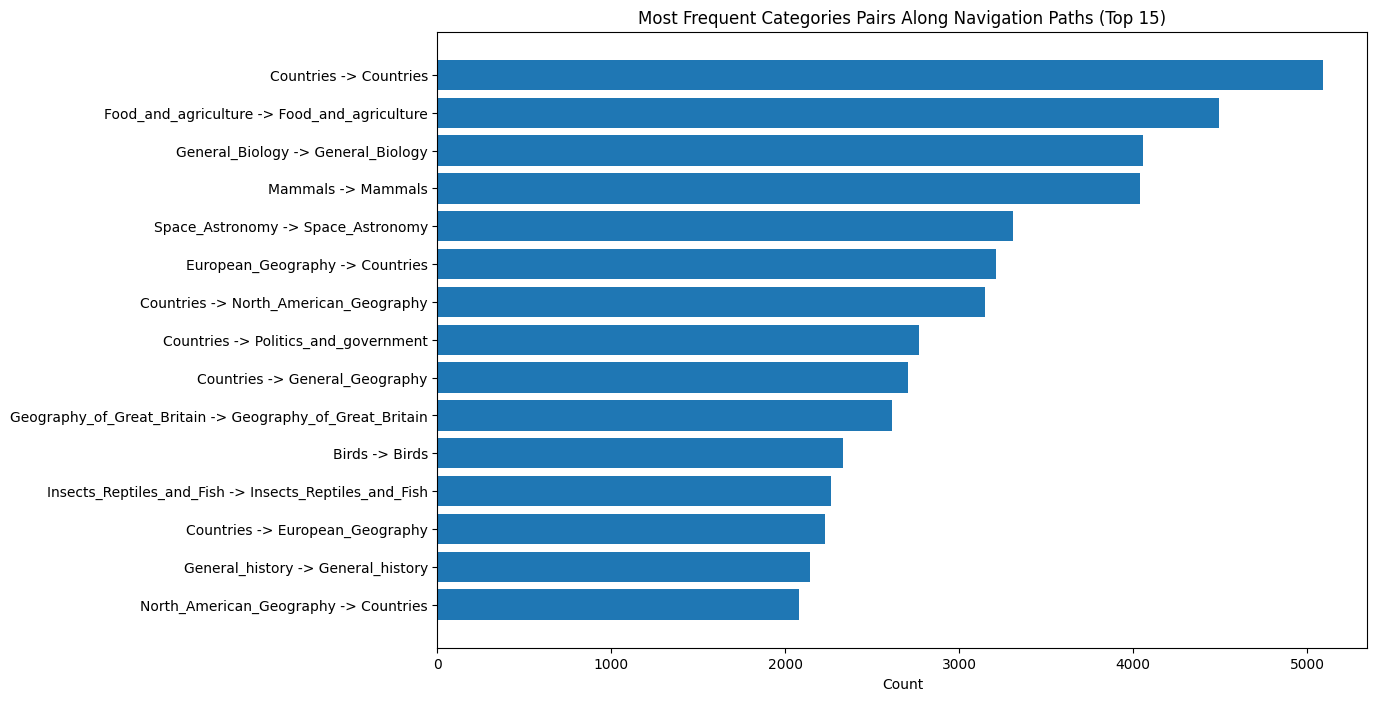

In [12]:
cat_shift_df_filter = preprocessor.get_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_categorical_shifts(cat_shift_df_filter, 'top_categorical_shifts.png')

The most frequent categories often occur for same categories, i.e., the user traverse articles within the same category. Below we exclude same category pairs.

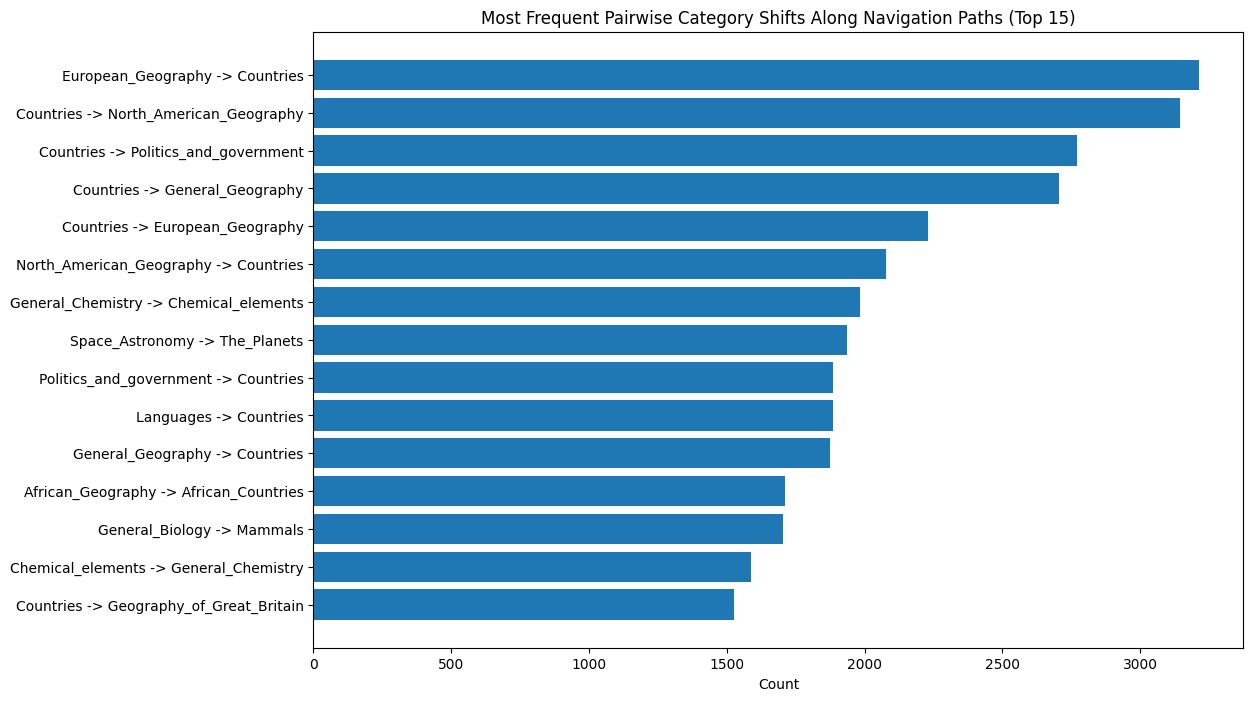

In [13]:
cat_shift_df_filter = preprocessor.get_pairwise_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_pairwise_categorical_shifts(cat_shift_df_filter, 'top_pairwise_categorical_shifts.png')

The 15 most frequent pairwise category shifts are categories that are related. 

Visualizing the categorical drifts along nagivation for a finished path: Interactive only inside notebook (see cat_shift.png for static image)

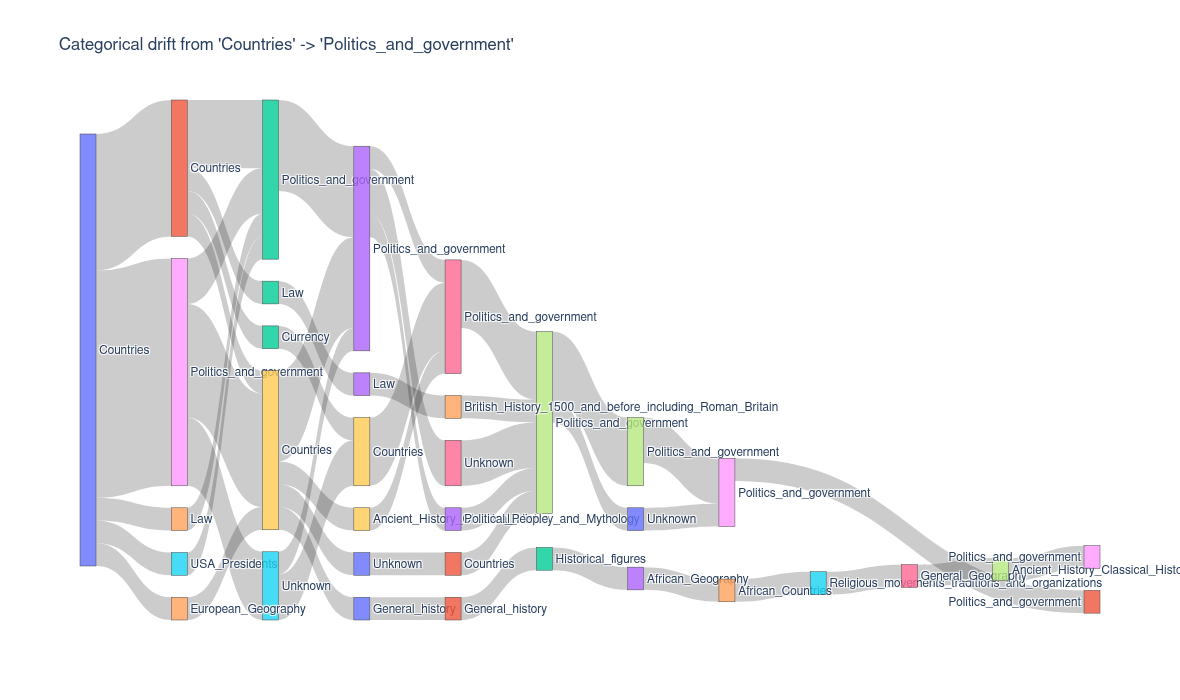

In [14]:
# Define start and end category
start_cat, end_cat = "Countries", "Politics_and_government"
cat_shift_df_pairs = preprocessor.get_category_shifts_df_pairs(article_cats_finished, start_cat, end_cat)

# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot.png'
visualizer.visualize_sankey_plot(cat_shift_df_pairs, filename, start_cat, end_cat)

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

<h3>Paths</h3>

We have access to many paths; there are 51,318 finished paths in total and 24,875 unfinished paths.

In [15]:
#number of finished vs unfinished paths
print('num of finished paths:', len(df[df['target'].isnull()]))
print('num of unfinished paths:', len(df[df['target'].notnull()]))

num of finished paths: 51318
num of unfinished paths: 24875


some paths have '<' in them, indicating backtracking by human players

we can simply resolve them by skipping back to the previous article and continuing from there

In [16]:
df[df['path'].astype(str).str.contains('<')].head(10)['path']

10    14th_century;Time;Science;Nature;Weather;Sunli...
13    14th_century;Renaissance;Empiricism;Nature;Wea...
14    14th_century;Renaissance;Leonardo_da_Vinci;Wat...
16    14th_century;Europe;Republic_of_Ireland;<;<;Eu...
19    14th_century;Time;Physics;<;Day;Sun;Sunlight;U...
36    14th_century;England;London;Spanish_Armada;Eng...
41    14th_century;Europe;<;England;<;Christianity;A...
42    2004_Atlantic_hurricane_season;U.S._state;Unit...
47    2004_Atlantic_hurricane_season;El_Niño-Souther...
49    2004_Atlantic_hurricane_season;Atlantic_Ocean;...
Name: path, dtype: object

In [17]:
resolved_df = preprocessor.resolve_all_parsed_paths(df.copy())

In [18]:
#check if all '<' are resolved
print('num of paths with < after resolution:', resolved_df['path'].astype(str).str.contains('<').sum())

num of paths with < after resolution: 0


Some finished paths have a length of 1, indicating that the player is already at the target article, so we can simply remove those paths


In [19]:
print('num of finished paths with length 1 before removal:', len(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)]))

num of finished paths with length 1 before removal: 11


In [20]:
# remove finished paths with length 1
filtered_finished_paths = resolved_df.drop(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)].index)

<h3>Difficulties</h3>

Lets get the distribution of difficulties for finished and unfinished paths:

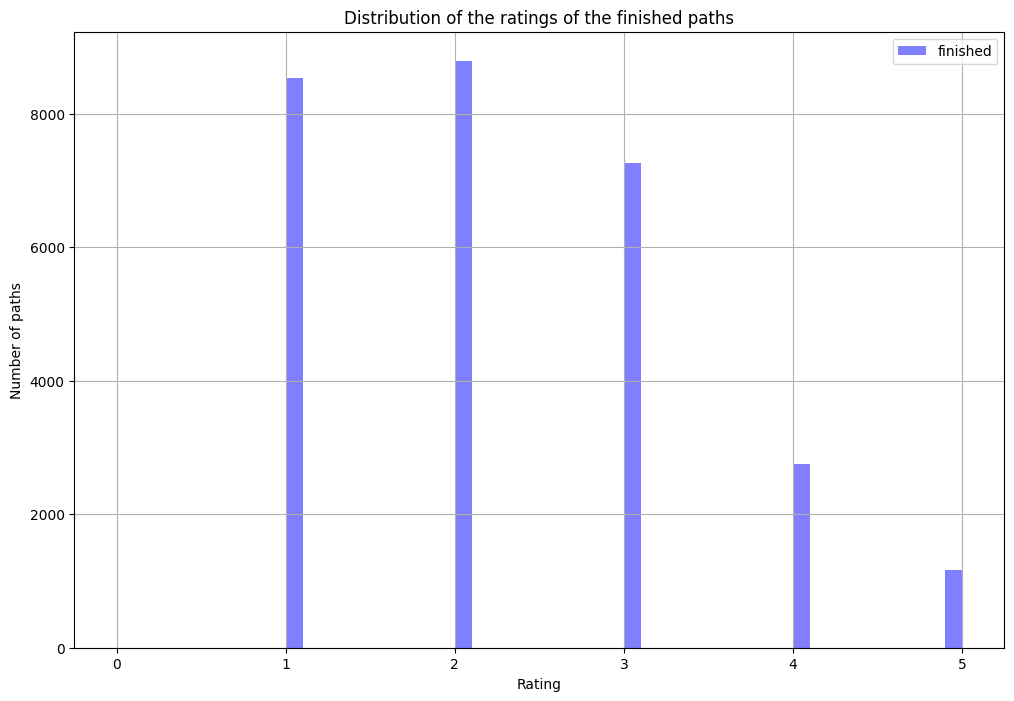

In [21]:
#get the distribution of difficulties for finished and unfinished paths
visualizer.visualize_ratings_distribution(filtered_finished_paths, 'ratings_distribution.png')

The rating distribution is imbalanced, so before conducting our further experiments, we can potentially stratify the dataset based on rating.

<h3>Durations</h3>

We are interested in the distribution of durations for unfinished paths:

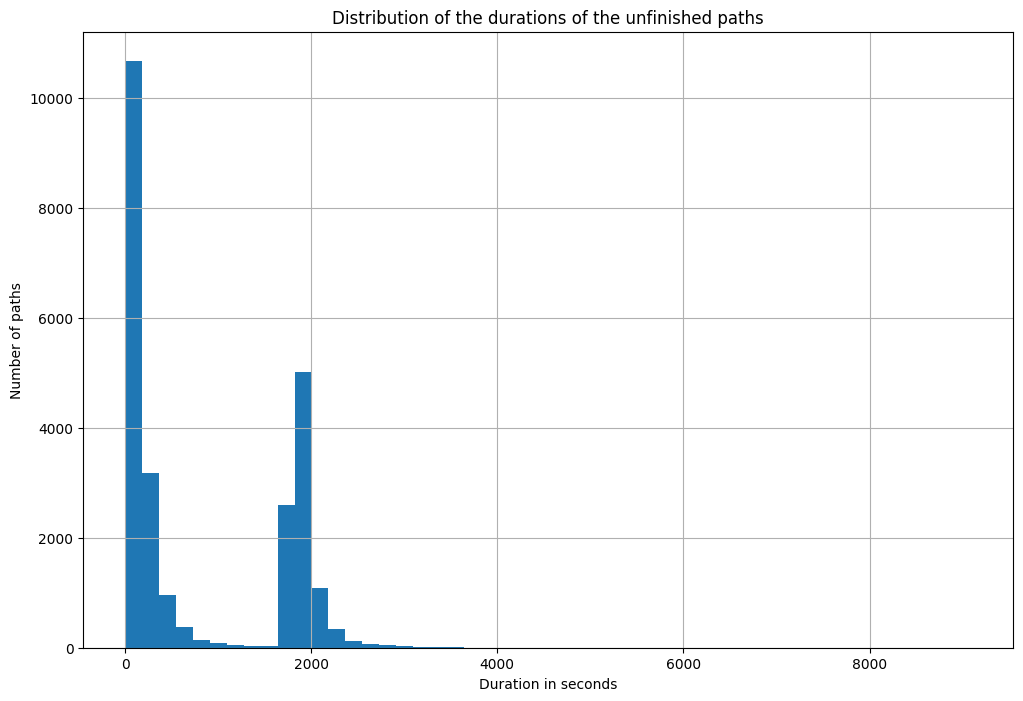

In [22]:
#Duration and rating correlation
visualizer.visualize_duration_distribution_unfinished(df, 'unfinished_duration_distribution.png')

Unfinished paths have two types: restart and timeout. It is two distinct distributions! Timeouts are longer.

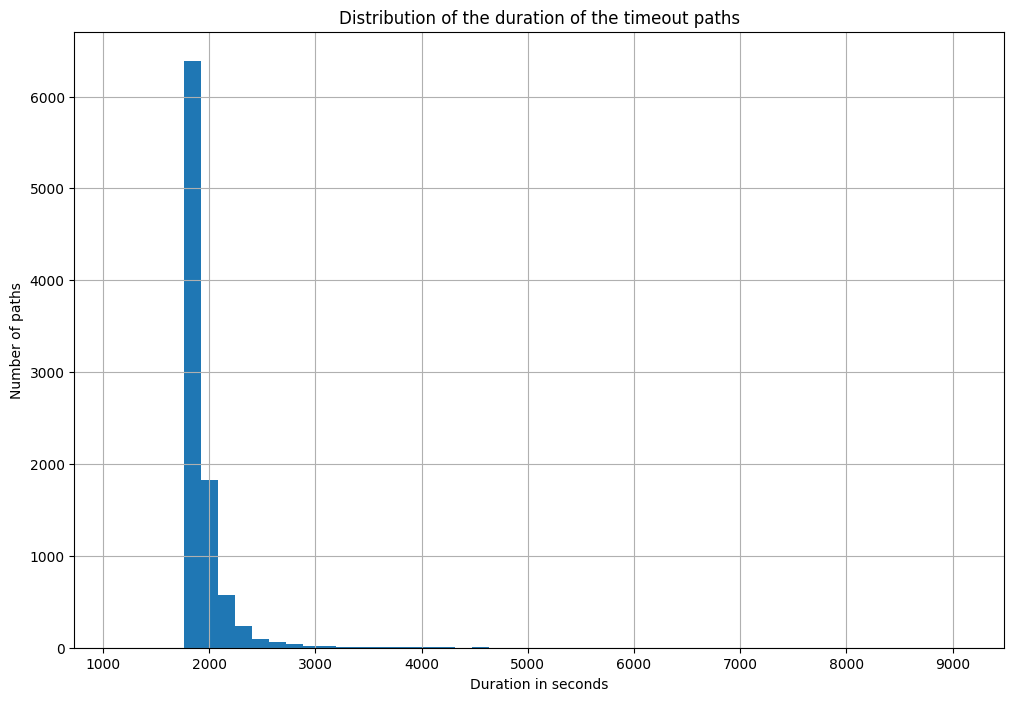

In [23]:
visualizer.visualize_duration_distribution_unfinished_timeout(df, 'unfinished_duration_distribution_timeout.png')

The plot confirms that the duration of timeout paths are an independent distribution from restart paths.

<h3>Semantics</h3>

We can visualize the semantic space of all articles using their embeddings obtained by sentence transformers:   

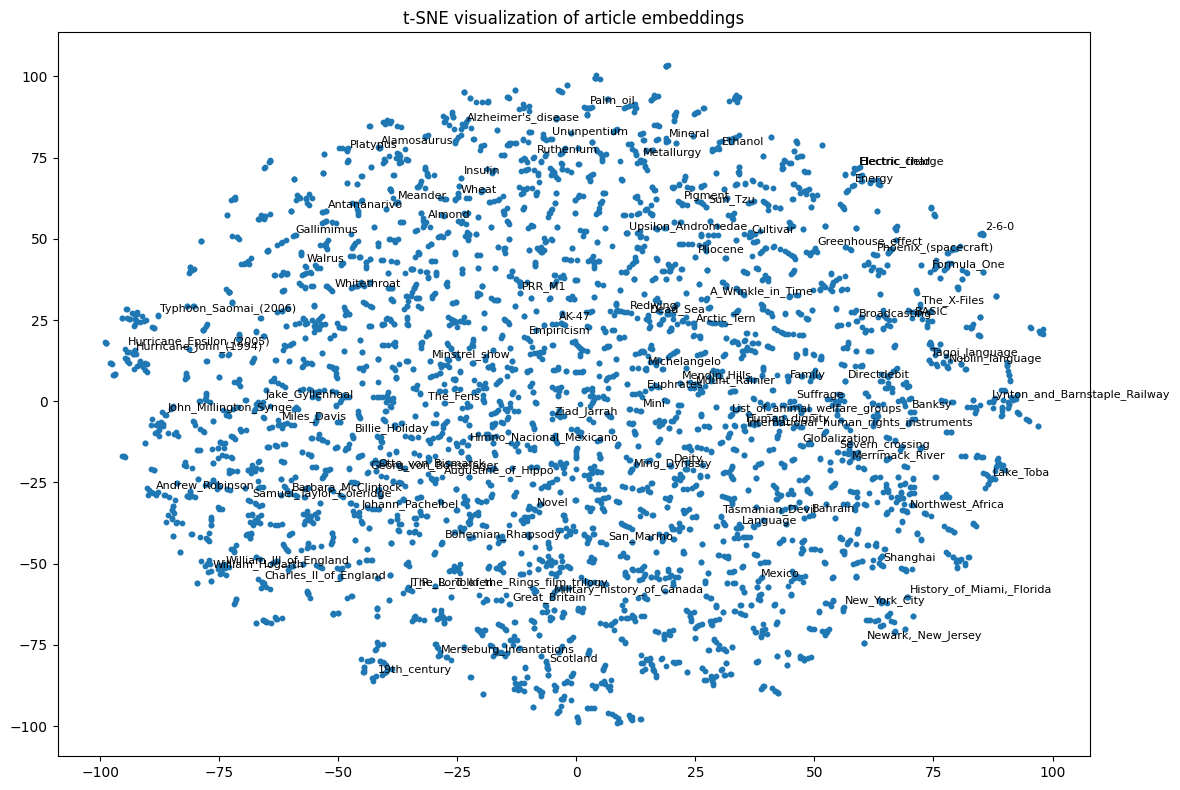

In [24]:
#semantic distribution of articles
visualizer.visualize_semantic_space(
    filename="semantic_space.png",
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt"
)

We can also visualize the association between average hops and average rating for the top start-destination paths. The result indicates that more difficult paths (lower rating) tend to have more hops on average.

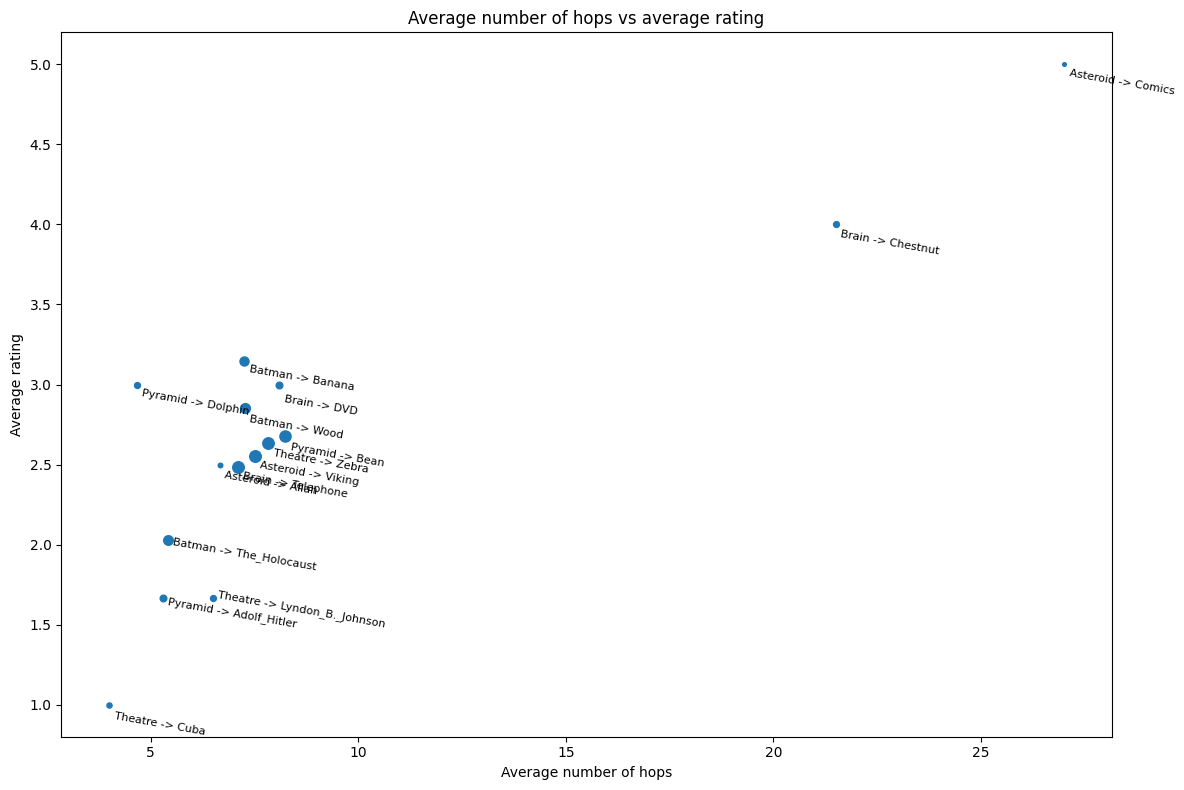

In [25]:
# average hops vs average rating within the above start-destination paths (only for finished paths), scatters are corrected by count [np.log() * 10]
visualizer.visualize_top_k_avg_hops(top_k_df, 'average_hops_vs_average_rating.png')

Below is the hop distribution for paths from Brain to Telephone, only considering finished paths:

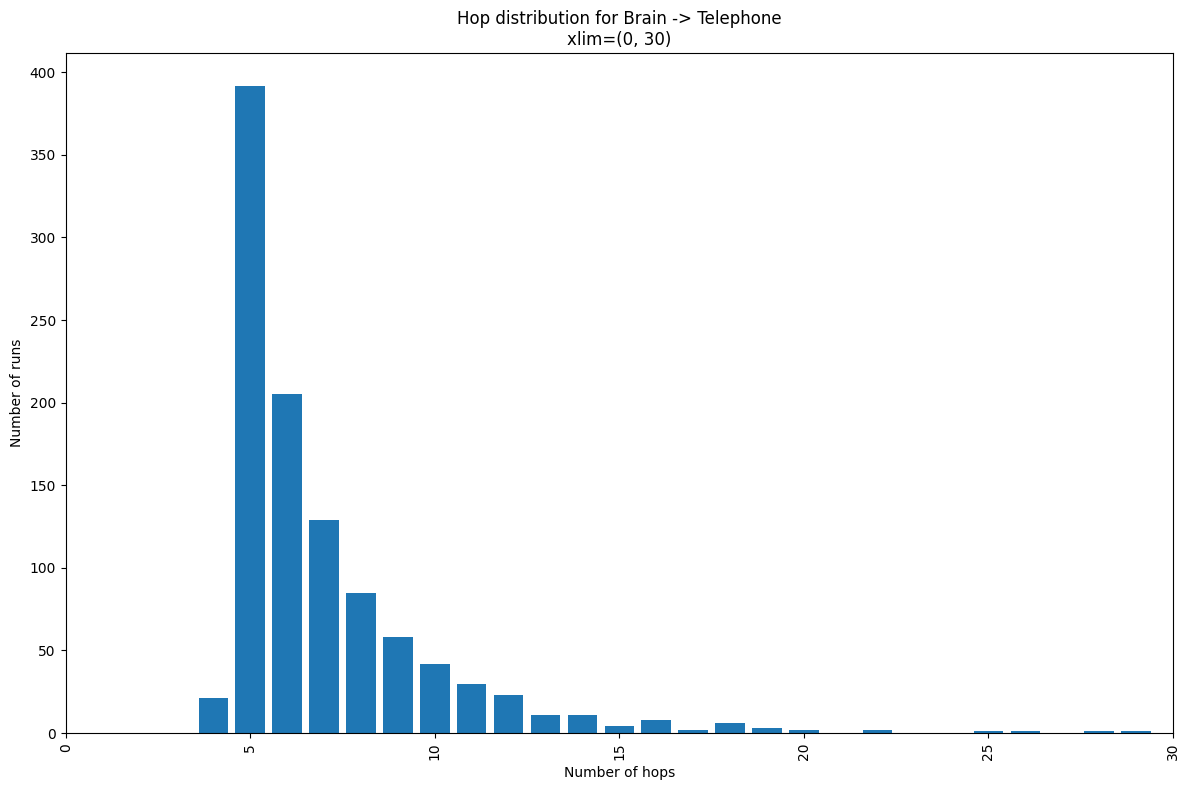

In [26]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

We can see that most paths from Brain to Telephone have around 5 hops.

<h2>Information Gain Analysis</h2>

We can analyze the information gain along the navigation paths from start to destination. The information gain is calculated based on the cosine similarity between current article and target article embeddings obtained from a sentence transformer model. Below is an example of analyzing the information gain for paths from "Brain" to "Telephone".

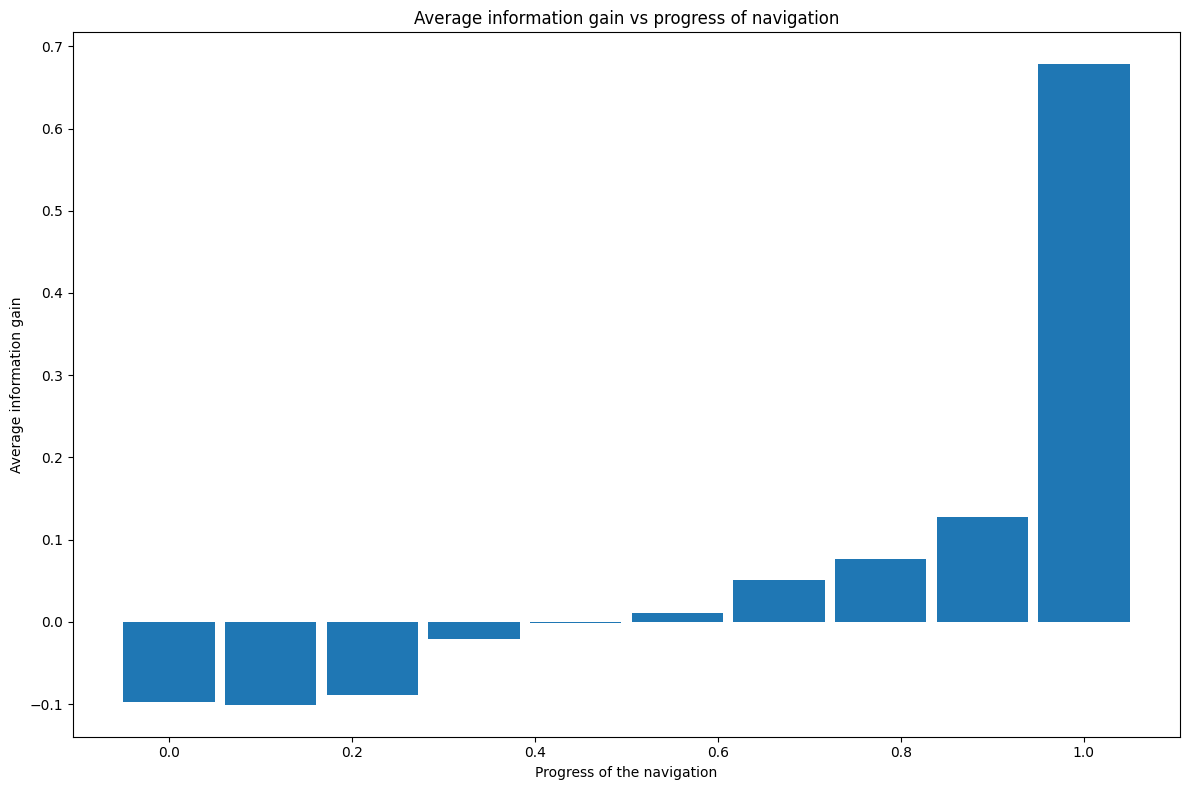

In [27]:
# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

Here we have an example test on path generation using a LLM agent. The agent uses the Tree of Thoughts (ToT) approach to generate navigation paths from start to destination.

In [28]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)
llm_tot_path = agent.navigate_tot(start, destination)
f'Path generated by LLM using ToT: {llm_tot_path}'

"Path generated by LLM using ToT: ['Brain', 'Computer_science', 'Internet', 'World_Wide_Web', 'Telephone']"